# Streaming Decoder Visualizations

This notebook visualizes results saved by `save_split_results()` / `load_split_results()`.

Each split is stored in two files:
- `{split}_metadata.parquet` — scalar + list columns (WER, glosses, predictions, segments)
- `{split}_arrays.npz` — per-frame logit arrays (logits, probs, labels, states)

**Cells are organized by visualization type:**
1. Imports & Constants
2. I/O Helpers
3. Color Palette Helpers
4. Plot 1 — Sequence Timeline
5. Plot 2 — Post-bag Confidence Heatmap
6. Plot 3 — WER Distribution
7. Plot 4 — Split Overview Grid
8. Plot 5 — Sign-level Confusion Matrix
9. Convenience — Batch Export All Sequences
10. Run Everything

---
## 1. Imports & Constants

In [1]:
from __future__ import annotations

import json
import os
from typing import Sequence

import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

# ---------------------------------------------------------------------------
# Constants — must match the values used in the decoder
# ---------------------------------------------------------------------------

# Directory where the .parquet and .npz result files live
RESULTS_DIR = "./"

# Frames per second captured by the Leap Motion sensor
LEAP_FPS = 30

# Number of consecutive frames whose votes are majority-pooled before
# committing a label (the "bag" in bag-of-frames decoding)
BAG_SIZE = 5

# Minimum post-bag top-1 probability required to accept a sign prediction
CONFIDENCE_THRESHOLD = 0.35

# Minimum gap between the top-1 sign probability and the background probability;
# if the gap is smaller the frame is treated as background
SIGN_BG_MARGIN = 0.10

# Label string used for the background / no-sign class
BACKGROUND_LABEL = "background"  # change if your project uses a different name

# {class_index: label_string} — must match the mapping used during training.
# Replace with your actual vocabulary dict.
id_to_label = {
    0: "AUGUST",
    1: "BIG",
    2: "BIRD",
    3: "BOAT",
    4: "COME",
    5: "DRIVER",
    6: "FARMING",
    7: "FEBRUARY",
    8: "GO",
    9: "GREETINGS",
    10: "OUR",
    11: "READ",
    12: "SMALL",
    13: "TIGER",
    14: "TRAIN",
    15: "UGLY",
    16: "VAN",
    17: "WHAT",
    18: "WHICH",
    19: "WRITE",
    20: "background",
}



---
## 2. I/O Helpers
Functions to load saved split results from disk and extract per-sequence arrays.

In [2]:
def load_split_results(
    split_name: str,
    results_dir: str = RESULTS_DIR,
) -> tuple[pd.DataFrame, dict]:
    """
    Load metadata DataFrame and per-frame arrays for one split.

    Reads two files written by save_split_results():
        {slug}_metadata.parquet  — WER scalars, GT glosses, predictions,
                                   emit_regions and gt_segments (as JSON strings)
        {slug}_arrays.npz        — per-frame logit/prob/label/state arrays

    Parameters
    ----------
    split_name  : e.g. "test", "dev_val", "test_(user1)" — must match
                  the slug used when saving
    results_dir : directory containing the parquet / npz files

    Returns
    -------
    df     : DataFrame with all scalars + list columns
    arrays : dict keyed by "{row_idx}__{rec_id}__{field}"
    """
    slug = (
        split_name.lower()
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
    )
    parquet_path = os.path.join(results_dir, f"{slug}_metadata.parquet")
    npz_path     = os.path.join(results_dir, f"{slug}_arrays.npz")

    df = pd.read_parquet(parquet_path)

    def _deserialize_regions(x) -> list[tuple]:
        if not isinstance(x, str):
            return []
        out = []
        for r in json.loads(x):
            if isinstance(r, dict):
                # gt_segments saved as dicts — extract values by key
                out.append((int(r["start_frame"]), int(r["end_frame"]), str(r["label"])))
            elif isinstance(r, (list, tuple)) and len(r) >= 3:
                # emit_regions saved as lists — cast directly
                out.append((int(r[0]), int(r[1]), str(r[2])))
        return out

    for col in ["emit_regions", "gt_segments"]:
        if col in df.columns:
            df[col] = df[col].apply(_deserialize_regions)

    npz    = np.load(npz_path, allow_pickle=True)
    arrays = {k: npz[k] for k in npz.files}

    return df, arrays


def get_sequence_arrays(row: pd.Series, arrays: dict) -> dict:
    """
    Extract all per-frame arrays for a single DataFrame row.

    Constructs the key prefix from the row index and recording_id,
    then pulls every stored field from the shared arrays dict.

    Returns
    -------
    dict with keys:
        pre_bag_logits  (T, C) float32  — raw model logits before bag pooling
        post_bag_probs  (T, C) float32  — softmax probs after bag; first
                                          (BAG_SIZE-1) rows are NaN
        frame_indices   (T,)   int32    — original frame numbers
        raw_labels      (T,)   object   — per-frame pre-bag top-1 label string
        voted_labels    (T,)   object   — post-bag majority-vote label string
        raw_conf        (T,)   float32  — pre-bag top-1 confidence
        bg_conf         (T,)   float32  — post-bag background class confidence
        states          (T,)   object   — decoder FSM state string per frame
    """
    row_idx = row.name
    rec_id  = str(row["recording_id"]).replace("/", "_")
    prefix  = f"{row_idx}__{rec_id}"

    fields = [
        "pre_bag_logits", "post_bag_probs",
        "frame_indices",
        "raw_labels",     "voted_labels",
        "raw_conf",       "bg_conf",
        "states",
    ]
    return {f: arrays.get(f"{prefix}__{f}") for f in fields}


def _safe_segment_tuple(seg):
    """Convert a segment tuple/list/dict to (int start, int end, str label).
    Returns None if the input cannot be safely cast."""
    if isinstance(seg, dict):
        try:
            return (int(seg["start_frame"]), int(seg["end_frame"]), str(seg["label"]))
        except (KeyError, ValueError, TypeError):
            return None
    if isinstance(seg, (tuple, list)) and len(seg) >= 3:
        try:
            return (int(seg[0]), int(seg[1]), str(seg[2]))
        except (ValueError, TypeError):
            pass
    return None

---
## 3. Color Palette Helpers
Builds a stable color mapping from label strings to RGBA tuples. Background is always light grey; sign labels get distinct colors from the tab20 colormap.

In [3]:
def _build_label_colors(
    all_labels: Sequence[str],
    background_label: str = BACKGROUND_LABEL,
    cmap_name: str = "tab20",
) -> dict[str, tuple]:
    """
    Assign a stable, distinct color to every label.

    - Background label is always rendered as light grey so it never
      visually competes with actual sign labels.
    - Sign labels are sorted alphabetically before colors are assigned
      so the mapping is reproducible across calls with different label
      subsets (as long as the full vocabulary is the same).

    Parameters
    ----------
    all_labels       : full set of label strings seen in this context
    background_label : the label name to paint grey
    cmap_name        : matplotlib colormap to sample sign colors from

    Returns
    -------
    dict mapping label string → RGBA tuple
    """
    sign_labels = sorted(set(all_labels) - {background_label})

    # Support both old (get_cmap) and new (colormaps[]) matplotlib APIs
    try:
        cmap = plt.colormaps[cmap_name]
    except AttributeError:
        cmap = plt.cm.get_cmap(cmap_name)

    colors = [cmap(i) for i in range(len(sign_labels))] if sign_labels else []
    color_dict = {lbl: colors[i] for i, lbl in enumerate(sign_labels)}
    color_dict[background_label] = (0.88, 0.88, 0.88, 1.0)  # light grey
    return color_dict

In [4]:
from pathlib import Path

def plot_sequence_timeline(
    row: pd.Series,
    arrays: dict,
    csv_path: str | Path | None = None,
    label_colors: dict | None = None,
    background_label: str     = "background",
    figsize: tuple            = (20, 11),
    title: str | None         = None,
    save_path: str | None     = None,
) -> plt.Figure:
    """
    [ignoring loop detection]
    Six-row timeline for one sequence.

    Row 0 - Ground-truth segmentation regions (colored bars)
    Row 1 - Missing frames (red blocks where both hands are lost)
    Row 2 - Per-frame pre-bag top-1 label strip (raw, noisy)
    Row 3 - Per-frame post-bag voted label strip (smoothed)
    Row 4 - Pre-bag top-1 probability curve (after softmax)
    Row 5 - Pre-bag top-2 probability curve (after softmax)

    Emit regions are shown across all rows as a shaded span with
    dotted vertical lines at start and end.
    """
    seq            = get_sequence_arrays(row, arrays)
    frames         = seq["frame_indices"]
    raw_labels     = seq["raw_labels"]
    voted_labels   = seq["voted_labels"]
    pre_bag_logits = seq["pre_bag_logits"]

    # ---- Softmax -> top-1 and top-2 probabilities ----------------------
    def softmax(x: np.ndarray) -> np.ndarray:
        e = np.exp(x - np.nanmax(x, axis=1, keepdims=True))
        return e / np.nansum(e, axis=1, keepdims=True)

    if pre_bag_logits is not None:
        pre_bag_probs = softmax(pre_bag_logits)
        sorted_probs  = np.sort(pre_bag_probs, axis=1)[:, ::-1]
        top1_prob     = sorted_probs[:, 0]
        top2_prob     = sorted_probs[:, 1]
    else:
        top1_prob = top2_prob = np.full(len(frames), np.nan)

    T            = frames[-1] + 1 if frames is not None and len(frames) > 0 else 1
    gt_segments  = row.get("gt_segments",  [])
    emit_regions = row.get("emit_regions", [])

    gt_segments  = [_safe_segment_tuple(s) for s in gt_segments  if _safe_segment_tuple(s)]
    emit_regions = [_safe_segment_tuple(r) for r in emit_regions if _safe_segment_tuple(r)]

    # ---- Missing Frame Calculation -----------------------------------
    missing_mask = None
    if csv_path is not None and Path(csv_path).exists():
        df_csv = pd.read_csv(csv_path)
        left_ok = (df_csv["left_confidence"] > 0) & (df_csv["left_palm_x"] != 0)
        right_ok = (df_csv["right_confidence"] > 0) & (df_csv["right_palm_x"] != 0)
        missing_mask = ~(left_ok | right_ok)

    # Build color palette
    all_labels  = set(raw_labels.tolist())   if raw_labels   is not None else set()
    all_labels |= set(voted_labels.tolist()) if voted_labels is not None else set()
    all_labels |= {seg[2] for seg in gt_segments}
    all_labels.add(background_label)

    if label_colors is None:
        label_colors = _build_label_colors(all_labels, background_label)

    # ------------------------------------------------------------------
    # Figure layout: 6 rows - height ratios 1 : 0.4 : 1 : 1 : 2 : 2
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs  = gridspec.GridSpec(
        6, 1, figure=fig,
        height_ratios=[1, 0.4, 1, 1, 2, 2],
        hspace=0.08,
    )
    ax0 = fig.add_subplot(gs[0])
    ax_miss = fig.add_subplot(gs[1])
    ax1 = fig.add_subplot(gs[2])
    ax2 = fig.add_subplot(gs[3])
    ax3 = fig.add_subplot(gs[4])
    ax4 = fig.add_subplot(gs[5])

    all_axes = [ax0, ax_miss, ax1, ax2, ax3, ax4]

    # Shared x-tick helper - every 30 frames
    xticks      = np.arange(0, T, 30)
    xticklabels = [f"f{int(x)}" for x in xticks]

    def _apply_xticks(ax, show_labels=False):
        ax.set_xticks(xticks)
        if show_labels:
            ax.set_xticklabels(xticklabels, fontsize=7, rotation=45, ha="right")
        else:
            ax.set_xticklabels([])
            ax.tick_params(bottom=False)
        ax.set_xlim(0, T)

    # ------------------------------------------------------------------
    # Helper - draw emit regions across a given set of axes
    # ------------------------------------------------------------------
    def _draw_emit_regions(axes, label_ax):
        for (start, end, label) in emit_regions:
            for ax in axes:
                # Light yellow shading for the emission span
                ax.axvspan(start, end, alpha=0.15, color="gold", zorder=0)
                # Dotted line at start
                ax.axvline(start, color="darkgreen", linewidth=1.0,
                           linestyle=":", alpha=0.9, zorder=2)
                # Dotted line at end
                ax.axvline(end, color="darkred", linewidth=1.0,
                           linestyle=":", alpha=0.9, zorder=2)
            # Label text at top of label_ax, centred on the span
            mid = (start + end) / 2
            label_ax.text(
                mid, 0.45, label,
                ha="center", va="top", fontsize=6.5, color="black",
                fontweight="bold", rotation=90, clip_on=True,
            )

    # ---- Row 0: GT segmentation regions --------------------------------
    if gt_segments:
        for (start, end, label) in gt_segments:
            color = label_colors.get(label, "steelblue")
            ax0.barh(
                0, end - start, left=start, height=0.6,
                color=color, edgecolor="black", linewidth=0.5,
            )
            cx = (start + end) / 2
            ax0.text(
                cx, 0, label,
                ha="center", va="center", fontsize=7, fontweight="bold",
                color="white" if sum(color[:3]) < 1.5 else "black",
                clip_on=True,
            )
    else:
        ax0.text(0.5, 0.5, "No GT segments available",
                 ha="center", va="center", transform=ax0.transAxes, fontsize=9)

    ax0.set_yticks([0])
    ax0.set_yticklabels(["GT"], fontsize=9)
    ax0.set_ylim(-0.5, 0.5)
    _apply_xticks(ax0, show_labels=False)
    ax0.set_title(
        title or (
            f"{row.get('user', '?')} | {row.get('recording_id', '?')} | "
            f"WER={float(row['wer']):.3f}  "
            f"GT: {row.get('ground_truth', '')}  "
            f"Pred: {row.get('prediction', '')}"
        ),
        fontsize=10, loc="left",
    )

    # ---- Row 1: Missing Frames -----------------------------------------
    if missing_mask is not None:
        missing_indices = np.where(missing_mask)[0]
        # Draw red lines for every missing frame
        for f_idx in missing_indices:
            ax_miss.axvline(x=f_idx, color='red', alpha=0.8, linewidth=1.5)

    ax_miss.set_yticks([0])
    ax_miss.set_yticklabels(["Missing"], fontsize=9, color="red")
    ax_miss.set_ylim(-0.5, 0.5)
    # Remove horizontal bar/grid line at y=0 to make vertical red lines pop
    ax_miss.spines['left'].set_visible(False)
    ax_miss.spines['right'].set_visible(False)
    ax_miss.spines['top'].set_visible(False)
    ax_miss.spines['bottom'].set_visible(False)
    ax_miss.tick_params(axis='y', left=False)
    _apply_xticks(ax_miss, show_labels=False)

    # ---- Row 2: pre-bag label strip ------------------------------------
    if raw_labels is not None and len(raw_labels) == len(frames):
        for i, fi in enumerate(frames):
            label = str(raw_labels[i])
            color = label_colors.get(label, "lightgrey")
            ax1.barh(0, 1, left=fi, height=0.6, color=color, edgecolor="none")

    ax1.set_yticks([0])
    ax1.set_yticklabels(["Pre-bag\nvote"], fontsize=9)
    ax1.set_ylim(-0.5, 0.5)
    _apply_xticks(ax1, show_labels=False)

    # ---- Row 3: voted label strip --------------------------------------
    if voted_labels is not None and len(voted_labels) == len(frames):
        for i, fi in enumerate(frames):
            label = str(voted_labels[i])
            color = label_colors.get(label, "lightgrey")
            ax2.barh(0, 1, left=fi, height=0.6, color=color, edgecolor="none")

    ax2.set_yticks([0])
    ax2.set_yticklabels(["Voted\nlabel"], fontsize=9)
    ax2.set_ylim(-0.5, 0.5)
    _apply_xticks(ax2, show_labels=False)

    # ---- Row 4: pre-bag top-1 probability ------------------------------
    # Use CONFIDENCE_THRESHOLD directly from config or pass it as an argument.
    # Assuming CONFIDENCE_THRESHOLD is defined in scope
    CONFIDENCE_THRESHOLD = 0.35 # Fallback if not defined
    try:
        from config import CONFIDENCE_THRESHOLD
    except:
        pass
        
    ax3.plot(frames, top1_prob, color="steelblue", linewidth=1.2, zorder=3)
    ax3.axhline(CONFIDENCE_THRESHOLD, color="red", linewidth=1.0,
                linestyle=":", label=f"Threshold ({CONFIDENCE_THRESHOLD})", zorder=1)
    ax3.set_ylabel("Top-1 prob", fontsize=9)
    ax3.set_ylim(0, 1.05)
    ax3.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
    ax3.legend(fontsize=8, loc="upper right")
    _apply_xticks(ax3, show_labels=False)

    # ---- Row 5: pre-bag top-2 probability ------------------------------
    ax4.plot(frames, top2_prob, color="darkorange", linewidth=1.2, zorder=3)
    ax4.set_ylabel("Top-2 prob", fontsize=9)
    ax4.set_ylim(0, 1.05)
    ax4.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
    ax4.set_xlabel("Frame index", fontsize=9)
    _apply_xticks(ax4, show_labels=True)

    # ---- Draw emit regions across all axes ----------------------------
    _draw_emit_regions(all_axes, label_ax=ax1)

    # Shared legend for label colors
    handles = [
        mpatches.Patch(color=c, label=l)
        for l, c in label_colors.items() if l != background_label
    ]
    handles.append(mpatches.Patch(color=label_colors[background_label], label=background_label))
    # Missing frames legend entry
    handles.append(Line2D([0], [0], color="red", linewidth=2.0, label="Missing Data"))
    
    handles.append(mpatches.Patch(color="gold", alpha=0.4, label="Emit span"))
    handles.append(Line2D([0], [0], color="darkgreen", linewidth=1.0,
                          linestyle=":", label="Emit start"))
    handles.append(Line2D([0], [0], color="darkred",  linewidth=1.0,
                          linestyle=":", label="Emit end"))
    fig.legend(
        handles=handles, loc="lower center", fontsize=7,
        ncol=min(len(handles), 8), bbox_to_anchor=(0.5, -0.02),
    )

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved -> {save_path}")
    else:
        plt.show()

    return fig


In [5]:
def plot_wer_distribution(
    df: pd.DataFrame,
    split_name: str       = "",
    figsize: tuple        = (14, 5),
    top_n_worst: int      = 10,
    save_path: str | None = None,
) -> plt.Figure:
    """
    Two-panel WER distribution plot for an entire split.

    Left  — Histogram of WER values with mean / median reference lines
             and sample-count + std annotation.
    Right — Per-user box plot (one box per unique user).
             If only one user is present, falls back to a per-sequence
             scatter plot so the panel is never empty.

    Also prints the top_n_worst sequences ranked by WER (descending).

    Parameters
    ----------
    df          : DataFrame returned by load_split_results()
    split_name  : shown in the figure suptitle
    top_n_worst : how many worst-WER sequences to print (default 10)
    save_path   : if given, saves figure here instead of displaying inline

    Note on double-display
    ----------------------
    plt.show() is intentionally NOT called here. Jupyter auto-renders the
    returned Figure object, so calling plt.show() would cause it to appear
    twice. When save_path is set, plt.close() is called to free memory.
    """
    fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)
    fig.suptitle(f"WER Distribution — {split_name}", fontsize=12)

    wer = df["wer"].dropna().values

    # ---- Left: WER histogram ------------------------------------------
    ax_hist.hist(wer, bins=20, color="steelblue", edgecolor="white", linewidth=0.5)
    ax_hist.axvline(wer.mean(),     color="red",    linewidth=1.5, linestyle="--",
                    label=f"Mean   {wer.mean():.3f}")
    ax_hist.axvline(np.median(wer), color="orange", linewidth=1.5, linestyle="--",
                    label=f"Median {np.median(wer):.3f}")
    ax_hist.set_xlabel("WER",   fontsize=9)
    ax_hist.set_ylabel("Count", fontsize=9)
    ax_hist.set_title("WER histogram", fontsize=10)
    ax_hist.legend(fontsize=8)
    ax_hist.set_xlim(0, max(1.0, wer.max() + 0.05))
    # Std + sample count in the top-right corner
    ax_hist.text(
        0.98, 0.97, f"n={len(wer)}\nstd={wer.std():.3f}",
        ha="right", va="top", transform=ax_hist.transAxes,
        fontsize=8, color="grey",
    )

    # ---- Right: per-user box plot (or scatter for single-user splits) --
    if "user" in df.columns and df["user"].nunique() > 1:
        users     = sorted(df["user"].unique())
        user_wers = [df.loc[df["user"] == u, "wer"].values for u in users]
        bp = ax_box.boxplot(
            user_wers, labels=users, patch_artist=True,
            medianprops=dict(color="red", linewidth=1.5),
        )
        for patch in bp["boxes"]:
            patch.set_facecolor("steelblue")
            patch.set_alpha(0.5)
        ax_box.set_xlabel("User", fontsize=9)
        ax_box.set_ylabel("WER",  fontsize=9)
        ax_box.set_title("WER by user", fontsize=10)
        ax_box.tick_params(axis="x", rotation=30)
        ax_box.set_ylim(0, max(1.0, wer.max() + 0.05))
    else:
        # Single user: show per-sequence scatter instead
        ax_box.scatter(df["sample_idx"], df["wer"],
                       color="steelblue", s=25, alpha=0.7)
        ax_box.set_xlabel("Sequence index", fontsize=9)
        ax_box.set_ylabel("WER",            fontsize=9)
        ax_box.set_title("WER per sequence", fontsize=10)
        ax_box.set_ylim(0, max(1.0, wer.max() + 0.05))

    # ---- Print top-N worst sequences ----------------------------------
    # Sort by WER descending; ties keep their original DataFrame order.
    # Prints: rank, recording_id, WER, user (if present), GT, prediction.
    n_to_show = min(top_n_worst, len(df))
    worst     = df.nlargest(n_to_show, "wer")

    print(f"\n{'='*60}")
    print(f"  Top {n_to_show} worst sequences — {split_name}")
    print(f"{'='*60}")
    for rank, (_, row) in enumerate(worst.iterrows(), start=1):
        rec_id  = row.get("recording_id", "—")
        wer_val = float(row["wer"])
        gt      = row.get("ground_truth", "—")
        pred    = row.get("prediction",   "—")
        user    = f"  user={row['user']}" if "user" in row and pd.notna(row["user"]) else ""
        print(f"  #{rank:<3} WER={wer_val:.3f}{user}")
        print(f"       id  : {rec_id}")
        print(f"       GT  : {gt}")
        print(f"       pred: {pred}")
        print()
    print(f"{'='*60}\n")

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved → {save_path}")
        plt.close(fig)  # free memory; no inline display needed when saving

    # No plt.show() — Jupyter renders the returned Figure automatically.
    # Calling plt.show() here would cause the plot to appear twice.
    return fig

In [6]:
# ============================================================
# Configuration — edit these before running
# ============================================================

def get_index(df, sequence_id: str):
	return df[test_df['recording_id'] == sequence_id].index[0]



# Splits to load (filenames must exist in RESULTS_DIR)
TEST_SPLIT = "test_user3_20260705t054057z"
VAL_SPLIT  = "val_user3_20260705t054057z"
# ============================================================
# Load splits
# ============================================================
test_df, test_arrays = load_split_results(TEST_SPLIT)
val_df,  val_arrays  = load_split_results(VAL_SPLIT)

print(f"Test split : {len(test_df)} sequences, mean WER={test_df['wer'].mean():.3f}")
print(f"Val  split : {len(val_df)}  sequences, mean WER={val_df['wer'].mean():.3f}")

Test split : 55 sequences, mean WER=0.152
Val  split : 33  sequences, mean WER=0.010


In [7]:
test_df['wer'].median()

0.0

In [8]:
test_df.iloc[0]

sample_idx                                                                1
split                                                          Test (user3)
user                                                                  user3
recording_id                                                       P3_S9_R5
num_frames                                                              750
missing_ratio                                                           0.0
gt_len                                                                    4
pred_len                                                                  4
raw_len                                                                 721
wer                                                                     0.5
stream_mode                                                  thct_net_batch
stream_delay_frames                                                       0
num_stream_predictions                                                  721
first_predic

In [9]:
test_df['wer'].mean()

0.1515151515151515

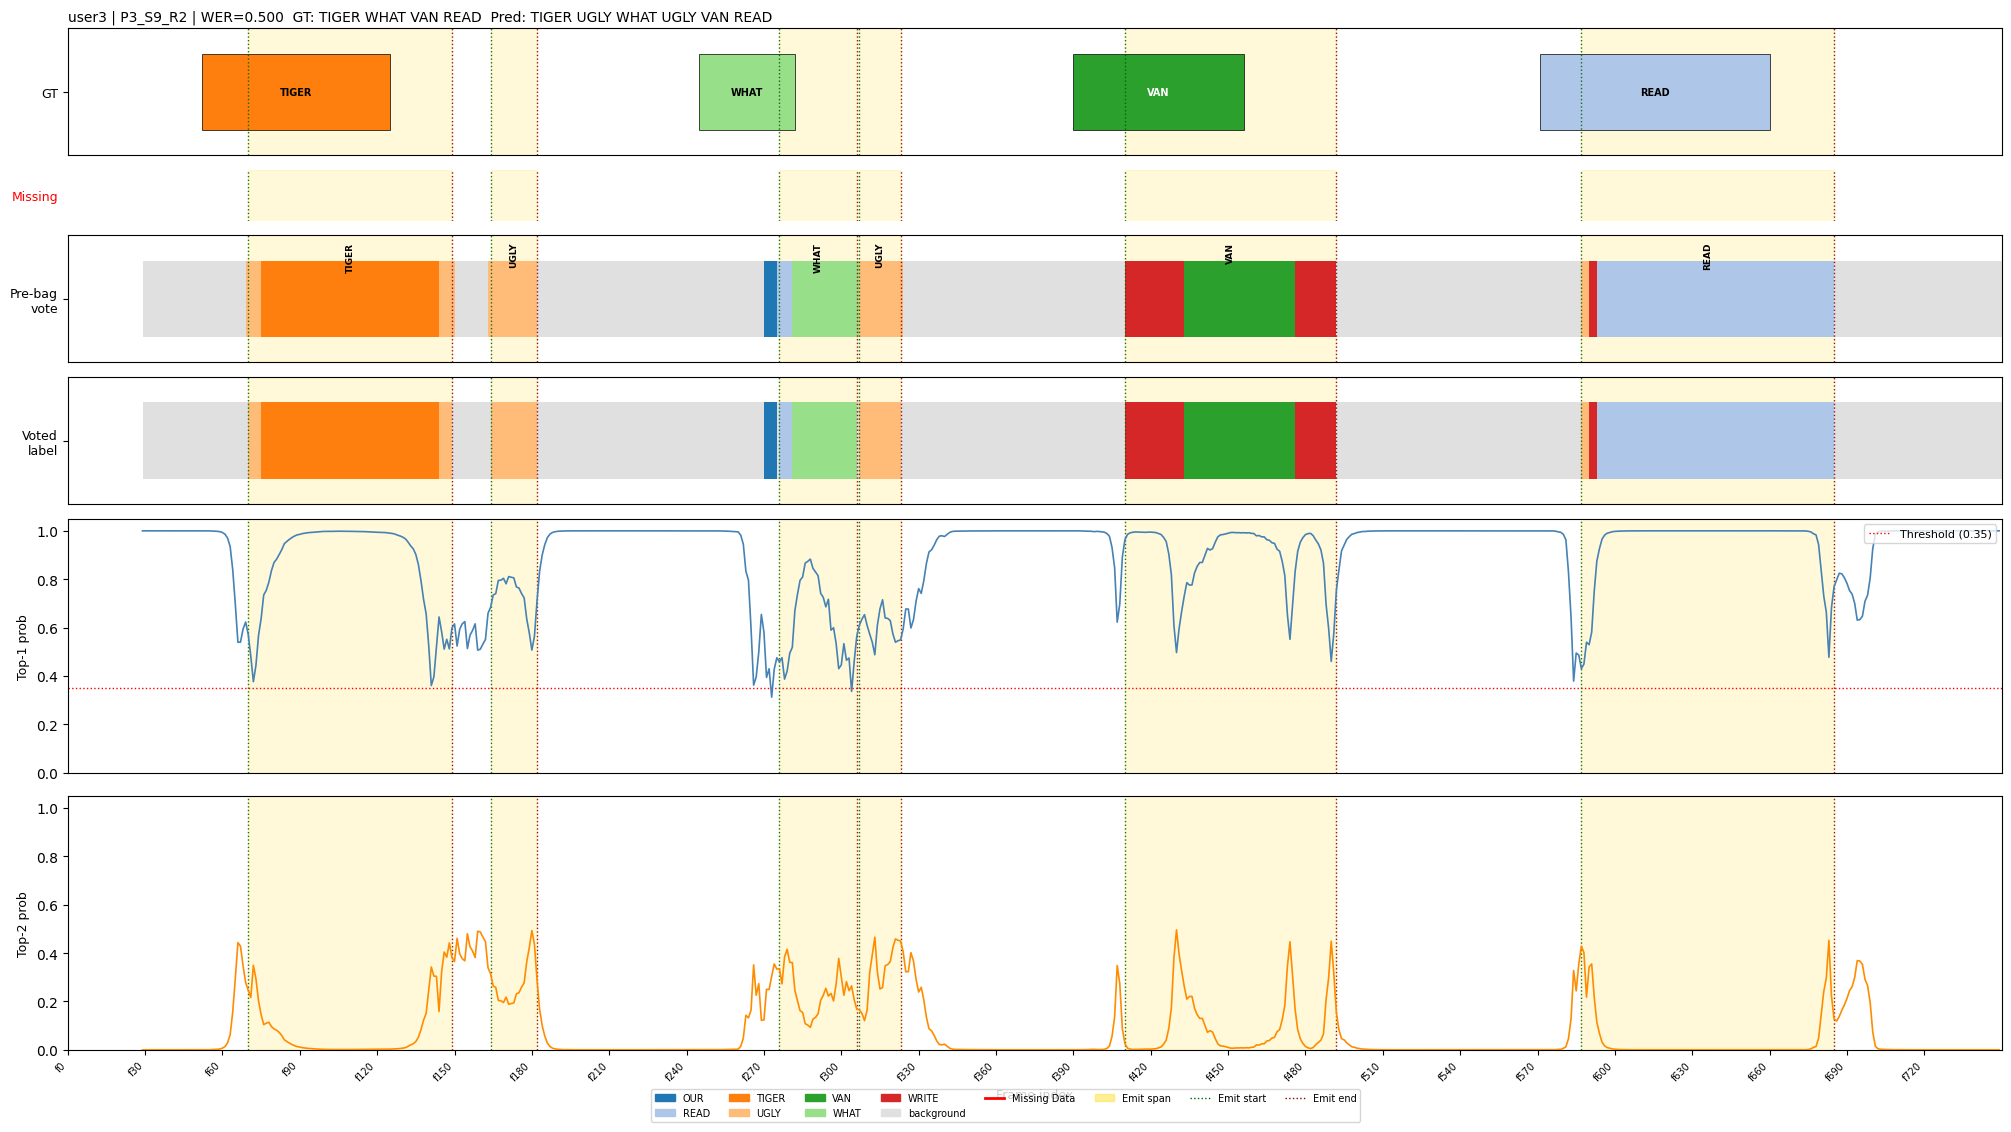

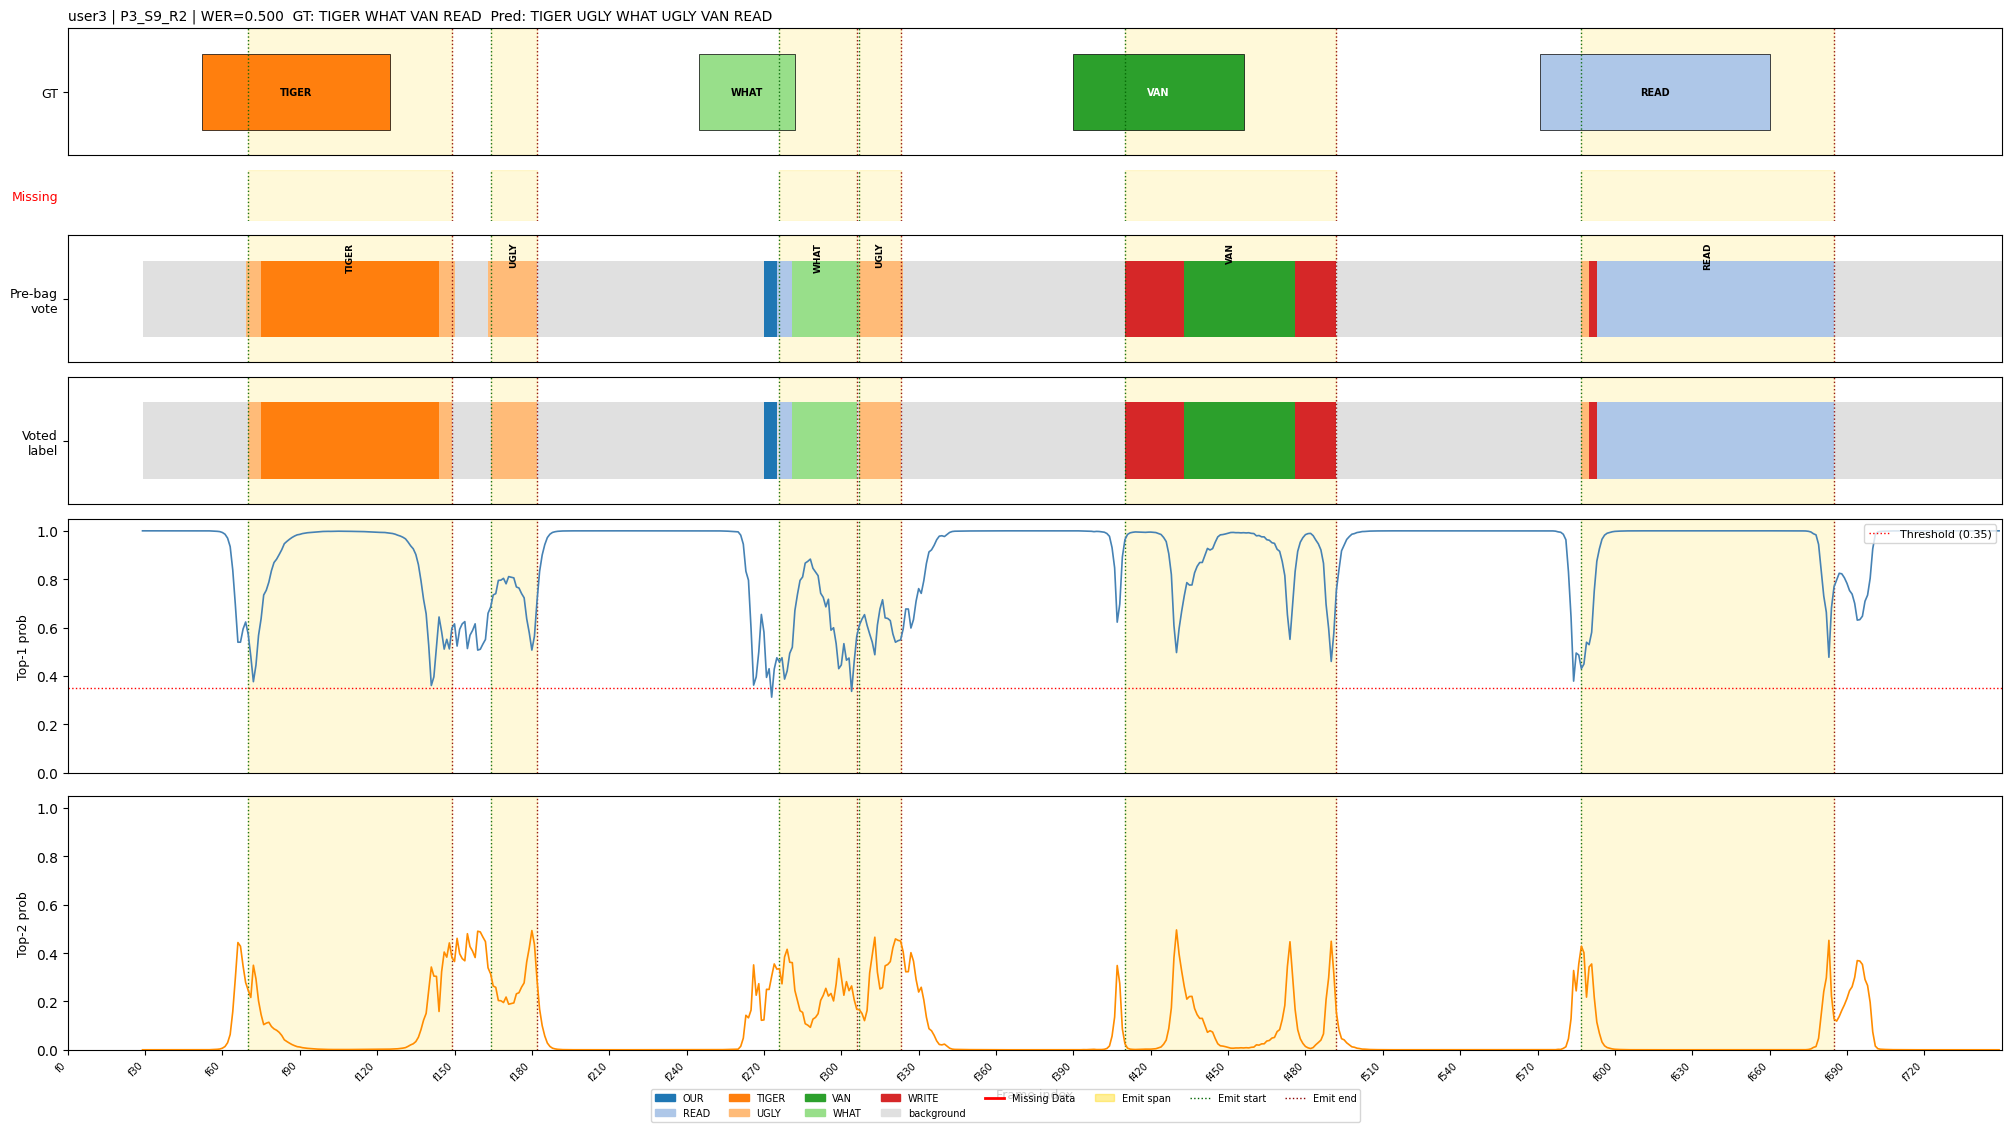

In [10]:
sequence_id = "P3_S9_R2"
user = "user1"
row = test_df.iloc[get_index(test_df, sequence_id)]

# Assuming the base dataset path. You might need to adjust this depending on the notebook's relative path
dataset_root = Path(f"c:/Shoab/Thesis/Experiments/dataset/")
user = row.get('user')  # Assuming this gets you "user1"
csv_path = dataset_root / user / "leap_data" / f"{sequence_id}.csv"

plot_sequence_timeline(row, test_arrays, csv_path=csv_path)


  Top 10 worst sequences — Test
  #1   WER=0.750  user=user3
       id  : P3_S5_R6
       GT  : BIRD WHAT DRIVER GREETINGS
       pred: DRIVER TRAIN DRIVER FEBRUARY

  #2   WER=0.500  user=user3
       id  : P3_S5_R4
       GT  : BIRD WHAT DRIVER GREETINGS
       pred: BIRD TRAIN DRIVER FEBRUARY

  #3   WER=0.500  user=user3
       id  : P3_S5_R5
       GT  : BIRD WHAT DRIVER GREETINGS
       pred: DRIVER TRAIN DRIVER GREETINGS

  #4   WER=0.333  user=user3
       id  : P3_S4_R3
       GT  : BOAT TRAIN TIGER
       pred: READ BOAT TRAIN TIGER

  #5   WER=0.250  user=user3
       id  : P3_S9_R5
       GT  : TIGER WHAT VAN READ
       pred: TIGER TRAIN VAN READ

  #6   WER=0.250  user=user3
       id  : P3_S9_R3
       GT  : TIGER WHAT VAN READ
       pred: TIGER TRAIN VAN READ

  #7   WER=0.250  user=user3
       id  : P3_S8_R6
       GT  : BIG GREETINGS WHICH FARMING
       pred: BIG FEBRUARY WHICH FARMING

  #8   WER=0.250  user=user3
       id  : P3_S1_R2
       GT  : GO READ OUR CO

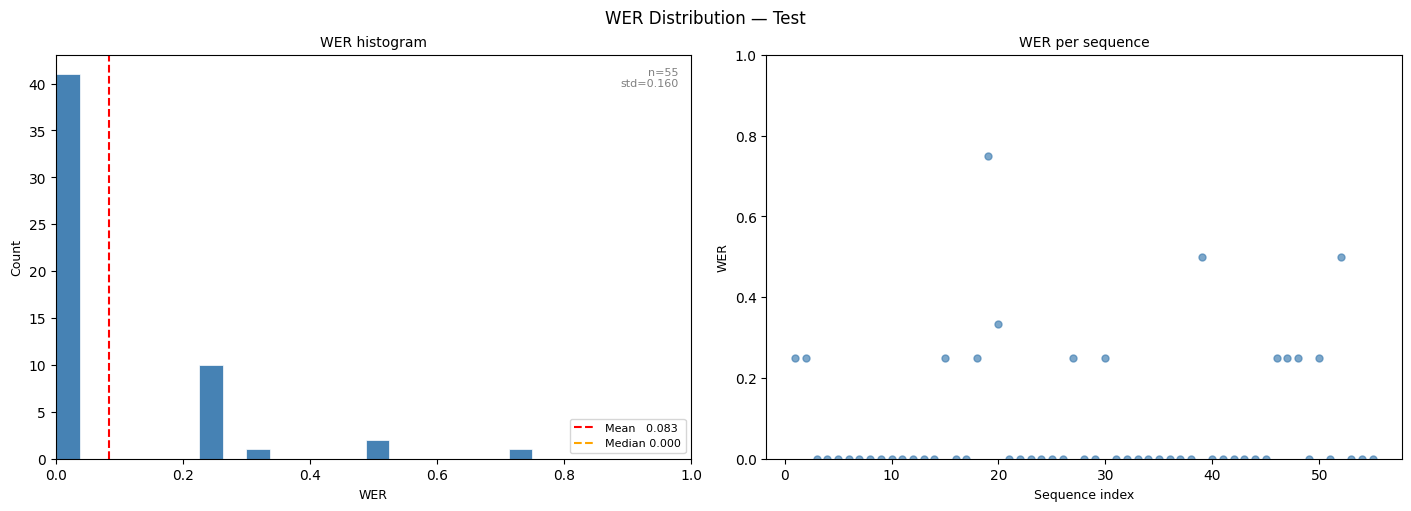

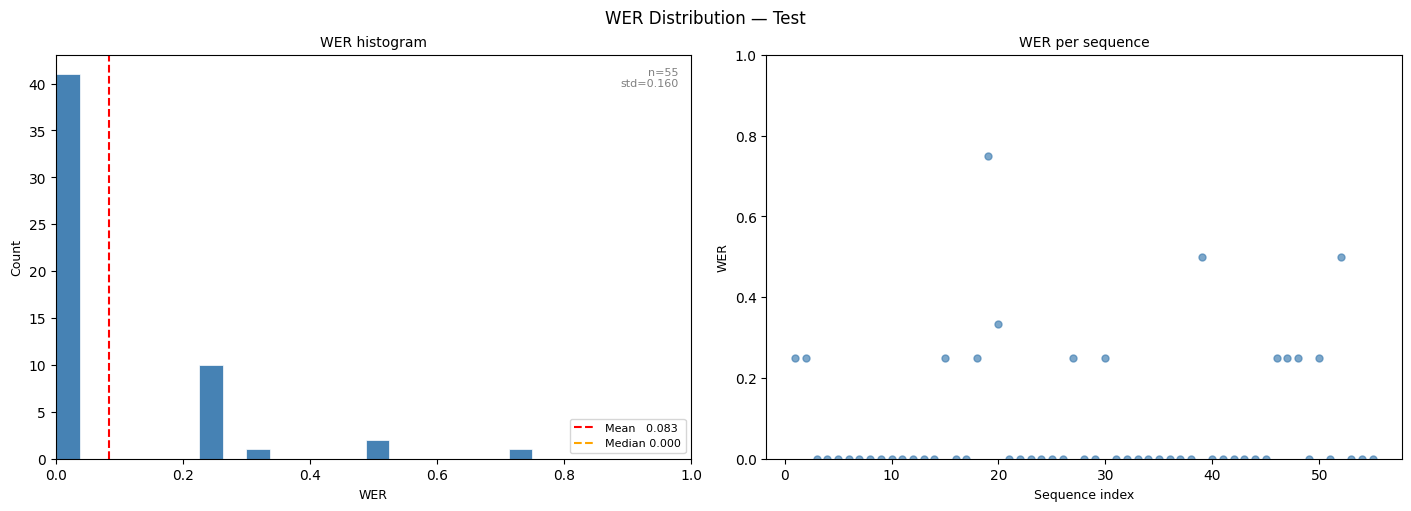

In [19]:
# ============================================================
# Plot 3 — WER distribution for the test split
# ============================================================
plot_wer_distribution(test_df, split_name="Test", top_n_worst=10)

# EXPLOARING DIFFERENT DECODER LOGIC

## Decoder + Metrics Replay (from saved logits)

Everything below is copied in directly (not imported) from `decoder.py`, `utils.py`, and
`metrics_corrected.py`, so it lives entirely inside this notebook and can be edited in place —
no `torch` dependency, no dependence on the project's `.py` sources.

Reproduces WER and SHREC'21 streaming metrics purely from the saved per-frame
`pre_bag_logits` / `frame_indices` arrays already loaded above (`test_arrays`, `val_arrays`).

In [11]:
# Additional decoder constants not already defined in the Imports & Constants cell above
# (BAG_SIZE, CONFIDENCE_THRESHOLD, SIGN_BG_MARGIN, id_to_label, BACKGROUND_LABEL are defined there)
BAG_AGGREGATION = "mean"
MIN_SIGN_MS     = 500
MIN_SIGN_FRAMES = max(1, round(MIN_SIGN_MS / 1000 * LEAP_FPS))

label_to_id = {v: k for k, v in id_to_label.items()}


In [12]:
from collections import Counter, deque

# ---------------------------------------------------------------------------
# Bag aggregator + streaming decoder — ported verbatim from decoder.py so it can
# be edited in place here without touching the project's .py sources.
#
# CAUTION: this is the core inference engine. Any changes here directly affect
# WER / streaming metrics results.
# ---------------------------------------------------------------------------

class _BagAggregator:
    """
    Causal sliding bag over raw logits.

    Why logits and not probs:
        Averaging in logit space is equivalent to a product-of-experts,
        which is sharper and more discriminative than averaging softmax probs.
        Converting to probs happens once after aggregation.

    Modes
    -----
    mean      : arithmetic mean of per-window probs after softmax
    max       : element-wise max of per-window probs
    attention : recency-weighted mean, most recent window weighted highest
    """

    def __init__(self, bag_size: int, aggregation: str, num_classes: int):
        self.bag_size    = max(1, int(bag_size))
        self.aggregation = aggregation
        self.num_classes = num_classes
        self._buffer     = deque(maxlen=self.bag_size)

    def update(self, logits: np.ndarray):
        """
        Push one logit vector and return aggregated probs.

        Returns None until bag is full (first bag_size frames are skipped).
        """
        self._buffer.append(logits.copy())

        if len(self._buffer) < self.bag_size:
            return None

        bag         = np.stack(self._buffer, axis=0)           # (bag_size, C)
        bag_shifted = bag - bag.max(axis=-1, keepdims=True)
        exp_bag     = np.exp(bag_shifted)
        probs       = exp_bag / exp_bag.sum(axis=-1, keepdims=True)  # (bag_size, C)

        if self.aggregation == "mean":
            return probs.mean(axis=0)

        if self.aggregation == "max":
            return probs.max(axis=0)

        if self.aggregation == "attention":
            weights  = np.linspace(0.5, 1.0, len(self._buffer))
            weights /= weights.sum()
            return (probs * weights[:, np.newaxis]).sum(axis=0)

        raise ValueError(f"Unknown aggregation mode: {self.aggregation}")

    def reset(self):
        self._buffer.clear()


class SimplifiedBagDecoder:
    """
    Causal streaming decoder using bag-aggregated logits.

    States
    ------
    SEEKING : waiting for a sign to begin
    IN_SIGN : inside an active sign region, accumulating votes

    Emission
    --------
    Fires at the TRAILING edge once `bg_exit_frames` consecutive background
    frames have been seen (default 1 = original behaviour: exit immediately
    on the first background frame). Emits the majority label observed across
    the entire region. Discards regions shorter than min_sign_frames (noise /
    glitches).
    """

    def __init__(
        self,
        id_to_label: dict,
        background_label: str,
        bag_size: int               = BAG_SIZE,
        aggregation: str            = BAG_AGGREGATION,
        confidence_threshold: float = CONFIDENCE_THRESHOLD,
        sign_bg_margin: float       = SIGN_BG_MARGIN,
        min_sign_frames: int        = MIN_SIGN_FRAMES,
        bg_exit_frames: int         = 1,
    ):
        self.id_to_label          = id_to_label
        self.background_label     = background_label
        self.confidence_threshold = float(confidence_threshold)
        self.sign_bg_margin       = float(sign_bg_margin)
        self.min_sign_frames      = max(1, int(min_sign_frames))
        self.bg_exit_frames       = max(1, int(bg_exit_frames))

        self.background_id = next(
            (k for k, v in id_to_label.items() if v == background_label), None
        )

        self._bag = _BagAggregator(bag_size, aggregation, len(id_to_label))

        # Hysteresis state
        self.state              = "SEEKING"
        self.region_votes       = Counter()
        self.sign_frames        = 0
        self.region_start_frame = None      # frame where current IN_SIGN region began
        self.bg_streak          = 0         # consecutive background frames seen while IN_SIGN

    # ------------------------------------------------------------------

    def _gate(self, agg_probs: np.ndarray):
        """
        Apply confidence gate to aggregated probabilities.

        Returns
        -------
        voted_label, is_background, pred_label, pred_conf, bg_conf, agg_probs
        """
        pred_id    = int(np.argmax(agg_probs))
        pred_label = self.id_to_label.get(pred_id, f"sign_{pred_id}")
        pred_conf  = float(agg_probs[pred_id])
        bg_conf    = (
            float(agg_probs[self.background_id])
            if self.background_id is not None else 0.0
        )

        is_sign = (
            pred_label != self.background_label
            and pred_conf  >= self.confidence_threshold
            and (pred_conf - bg_conf) >= self.sign_bg_margin
        )

        voted_label   = pred_label if is_sign else self.background_label
        is_background = not is_sign

        return voted_label, is_background, pred_label, pred_conf, bg_conf, agg_probs

    # ------------------------------------------------------------------

    def update(self, logits: np.ndarray, frame_index: int) -> dict:
        """
        Process one frame.

        Parameters
        ----------
        logits      : (C,) raw logits from model — stored as pre_bag_logits
        frame_index : int current frame index, needed for emit_region tracking
        """
        pre_bag_logits = logits.copy()              # capture before bag sees it
        agg_probs      = self._bag.update(logits)

        # Bag not full yet — stay in SEEKING, emit nothing
        if agg_probs is None:
            raw_probs = np.exp(logits - logits.max())
            raw_probs /= raw_probs.sum()
            return {
                "raw_label":      self.id_to_label.get(int(np.argmax(logits)), "?"),
                "raw_conf":       float(raw_probs.max()),
                "bg_conf":        0.0,
                "gated_label":    self.background_label,
                "voted_label":    self.background_label,
                "state":          self.state,
                "emitted_label":  None,
                "emit_region":    None,
                "pre_bag_logits": pre_bag_logits,   # (C,) always stored
                "post_bag_probs": None,             # bag not full yet
            }

        voted_label, is_background, pred_label, pred_conf, bg_conf, agg_probs = \
            self._gate(agg_probs)

        emitted_label = None
        emit_region   = None

        if self.state == "SEEKING":
            if not is_background:
                self.state              = "IN_SIGN"
                self.region_votes[voted_label] += 1
                self.sign_frames        = 1
                self.region_start_frame = frame_index   # record region start
                self.bg_streak          = 0

        elif self.state == "IN_SIGN":
            if not is_background:
                self.bg_streak = 0
                self.region_votes[voted_label] += 1
                self.sign_frames += 1
            else:
                # Background frame — only exit after bg_exit_frames consecutive
                # background frames (default 1 = original immediate-exit behaviour).
                self.bg_streak += 1
                if self.bg_streak >= self.bg_exit_frames:
                    # Trailing edge reached
                    if self.sign_frames >= self.min_sign_frames:
                        emitted_label = self.region_votes.most_common(1)[0][0]
                        emit_region   = (
                            self.region_start_frame,    # start of region
                            frame_index,                # end of region (trailing edge)
                            emitted_label,
                        )
                    # else: region too short → discard silently

                    self.state              = "SEEKING"
                    self.region_votes       = Counter()
                    self.sign_frames        = 0
                    self.region_start_frame = None
                    self.bg_streak          = 0
                # else: still within the background grace period — stay IN_SIGN,
                # this frame is not counted as a vote

        return {
            "raw_label":      pred_label,
            "raw_conf":       pred_conf,
            "bg_conf":        bg_conf,
            "gated_label":    voted_label,
            "voted_label":    voted_label,
            "state":          self.state,
            "emitted_label":  emitted_label,
            "emit_region":    emit_region,          # (start, end, label) or None
            "pre_bag_logits": pre_bag_logits,       # (C,) raw pre-bag logits
            "post_bag_probs": agg_probs,            # (C,) post-bag aggregated probs
        }

    # ------------------------------------------------------------------

    def flush(self):
        """
        Call once after all frames are processed.

        Emits any sign region still open at sequence end.

        Returns
        -------
        (emitted_label, emit_region)
        emit_region end frame is None — caller fills with t_len - 1.
        """
        emitted     = None
        emit_region = None

        if self.state == "IN_SIGN" and self.sign_frames >= self.min_sign_frames:
            emitted     = self.region_votes.most_common(1)[0][0]
            emit_region = (
                self.region_start_frame,
                None,       # end unknown — caller fills with t_len - 1
                emitted,
            )

        # Always reset — decoder is invalid after flush
        self.state              = "SEEKING"
        self.region_votes       = Counter()
        self.sign_frames        = 0
        self.region_start_frame = None
        self.bg_streak          = 0
        self._bag.reset()

        return emitted, emit_region


In [13]:
def compute_wer(pred: list, gt: list) -> float:
    """Compute Word Error Rate using Levenshtein edit distance. Ported from utils.py."""
    n, m = len(gt), len(pred)
    if n == 0:
        return 0.0 if m == 0 else 1.0

    dp = np.zeros((n + 1, m + 1), dtype=np.int32)
    for i in range(1, n + 1):
        dp[i, 0] = i
    for j in range(1, m + 1):
        dp[0, j] = j
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost     = 0 if gt[i - 1] == pred[j - 1] else 1
            dp[i, j] = min(
                dp[i-1, j] + 1, dp[i, j-1] + 1, dp[i-1, j-1] + cost,
            )

    return float(dp[n, m] / n)


In [14]:
def replay_decoder_from_logits(
    row: pd.Series,
    arrays: dict,
    id_to_label: dict = id_to_label,
    background_label: str = BACKGROUND_LABEL,
    **decoder_kwargs,
):
    """
    Replay SimplifiedBagDecoder over the saved per-frame pre_bag_logits/frame_indices
    for one sequence.

    This reproduces stream_model_online's output (decoder.py) without the model or raw
    features: stream_model_online only starts calling decoder.update() once its sliding
    window is full, and save_split_results stored exactly those per-frame logits/frame
    indices — so replaying update() over them in order, then flush() at the end,
    reconstructs the same stream_steps / emitted_preds / emit_regions.

    Returns
    -------
    stream_steps, emitted_preds, emit_regions — same shape as stream_model_online.
    """
    seq            = get_sequence_arrays(row, arrays)
    pre_bag_logits = seq["pre_bag_logits"]
    frame_indices  = seq["frame_indices"]

    decoder = SimplifiedBagDecoder(
        id_to_label=id_to_label,
        background_label=background_label,
        **decoder_kwargs,
    )

    stream_steps  = []
    emitted_preds = []
    emit_regions  = []

    for t in range(len(frame_indices)):
        decoded                = decoder.update(pre_bag_logits[t], frame_index=int(frame_indices[t]))
        decoded["frame_index"] = int(frame_indices[t])
        stream_steps.append(decoded)

        if decoded["emitted_label"] is not None:
            emitted_preds.append(decoded["emitted_label"])
        if decoded["emit_region"] is not None:
            emit_regions.append(decoded["emit_region"])

    final_emission, final_emit_region = decoder.flush()
    if final_emission is not None:
        t_len = int(row["num_frames"])
        if final_emit_region is not None:
            final_emit_region = (final_emit_region[0], t_len - 1, final_emit_region[2])
        emitted_preds.append(final_emission)
        emit_regions.append(final_emit_region)
        stream_steps.append({
            "raw_label":      final_emission,
            "raw_conf":       1.0,
            "bg_conf":        0.0,
            "gated_label":    final_emission,
            "voted_label":    final_emission,
            "state":          "FLUSH",
            "emitted_label":  final_emission,
            "emit_region":    final_emit_region,
            "pre_bag_logits": None,
            "post_bag_probs": None,
            "frame_index":    t_len - 1,
        })

    return stream_steps, emitted_preds, emit_regions


In [15]:
def _build_metrics_inputs_from_replay(
    row: pd.Series,
    stream_steps: list,
    emit_regions: list,
    label_to_id: dict,
    background_label: str = BACKGROUND_LABEL,
):
    """
    Convert replayed decoder output into the arrays expected by the SHREC'21 metrics
    module below. Adapted from evaluation.py's _build_metrics_inputs_from_wer_row —
    simplified because load_split_results (above) already normalizes gt_segments /
    emit_regions to (start, end, label) tuples.

    Returns
    -------
    frame_sequence, y_true, gating_list, y_pred_list, seq_len
    """
    seq_len = int(row["num_frames"])

    frame_sequence = []
    y_true = []
    for (start, end, label_str) in (row.get("gt_segments") or []):
        if label_str == background_label:
            continue
        cls_id = label_to_id.get(label_str)
        if cls_id is None:
            continue
        frame_sequence.append(int(start))
        frame_sequence.append(int(end))
        y_true.append(cls_id)

    gating_list = []
    for (start, end, _label) in emit_regions:
        gating_list.append(int(start))
        gating_list.append(int(end))

    y_pred_list = [-1] * seq_len
    bg_id = label_to_id.get(background_label)
    for step in stream_steps:
        fi = step.get("frame_index")
        if fi is None or fi < 0 or fi >= seq_len:
            continue
        voted_label_str = step.get("voted_label", background_label)
        if voted_label_str == background_label:
            continue
        cls_id = label_to_id.get(voted_label_str)
        if cls_id is not None and cls_id != bg_id:
            y_pred_list[fi] = cls_id

    return frame_sequence, y_true, gating_list, y_pred_list, seq_len


### SHREC'21 metrics module (ported from `metrics_corrected.py`)

In [16]:
# ---------------------------------------------------------------------------
# Corrected SHREC'21 online gesture recognition metrics, ported verbatim from
# metrics_corrected.py (Caputo et al., "SHREC 2021", Computers & Graphics, 2021).
# See that file's docstring for the full list of fixes vs. the original MATLAB
# reference script. Kept here (not imported) so it can be edited alongside the
# decoder above.
# ---------------------------------------------------------------------------

num_classes = 17

_global_total_gestures      = None   # GT count per class
_global_correct_predictions = None   # TP per class
_global_missed              = None   # GT gestures never overlapped by any pred
_global_misclassified       = None   # overlapped but wrong label
_global_false_positives     = None   # predictions that overlapped no GT
_global_latencies           = None   # latency samples per class
_global_jaccard_sum         = None   # running sum of overlap/union scores
_global_jaccard_counts      = None   # how many pairs contributed to jaccard_sum


def initialize_globals(n_classes=17):
    """Reset all global accumulators. Call once before the evaluation loop."""
    global num_classes
    global _global_total_gestures, _global_correct_predictions
    global _global_missed, _global_misclassified, _global_false_positives
    global _global_latencies, _global_jaccard_sum, _global_jaccard_counts

    num_classes                 = n_classes
    _global_total_gestures      = [0]   * num_classes
    _global_correct_predictions = [0]   * num_classes
    _global_missed              = [0]   * num_classes
    _global_misclassified       = [0]   * num_classes
    _global_false_positives     = [0]   * num_classes
    _global_latencies           = [[]   for _ in range(num_classes)]
    _global_jaccard_sum         = [0.0] * num_classes
    _global_jaccard_counts      = [0]   * num_classes


def _parse_intervals(flat_list):
    """Convert [s0, e0, s1, e1, ...] into [(s0,e0), (s1,e1), ...]."""
    n = len(flat_list) // 2
    return [(int(flat_list[2*i]), int(flat_list[2*i+1])) for i in range(n)]


def _overlap_ratio(s_true, e_true, s_pred, e_pred):
    """overlap / GT_length, no +1, matching MATLAB lines 73-76."""
    overlap   = min(e_true, e_pred) - max(s_true, s_pred)   # no +1, matches MATLAB
    gt_length = e_true - s_true
    if gt_length <= 0:
        gt_length = 1
    return overlap / gt_length


def _majority_class(y_pred_list, s, e):
    """
    Most frequent non-background class in y_pred_list[s:e+1].
    Both -1 and num_classes are treated as background and excluded.
    Returns None if every frame is background.
    """
    segment = [
        y_pred_list[i]
        for i in range(s, min(e + 1, len(y_pred_list)))
        if y_pred_list[i] not in (-1, num_classes)
    ]
    if not segment:
        return None
    return max(set(segment), key=segment.count)


def _build_pred_intervals(gating_list, y_pred_list):
    """Parse gating_list into a list of dicts: {start, end, class}."""
    intervals = []
    for (s, e) in _parse_intervals(gating_list):
        cls = _majority_class(y_pred_list, s, e)
        intervals.append({'start': s, 'end': e, 'class': cls})
    return intervals


def _compute_metrics(gt_intervals, gt_classes, pred_intervals, y_pred_list, n_classes):
    """
    Compute detection rate, misclassification, FPR, latency, and Jaccard in one
    pass, mirroring the MATLAB script structure (outer loop over predictions,
    inner loop over GT gestures).
    """
    total_gestures      = [0]   * n_classes
    correct_predictions = [0]   * n_classes
    missed              = [0]   * n_classes
    misclassified       = [0]   * n_classes
    false_positives     = [0]   * n_classes
    latencies           = [[]   for _ in range(n_classes)]
    jaccard_sum         = [0.0] * n_classes
    jaccard_counts      = [0]   * n_classes

    num_gt = len(gt_intervals)

    for i in range(num_gt):
        total_gestures[int(gt_classes[i])] += 1

    # found[i] = 1 if GT gesture i has already been matched to a TP prediction
    found = [0] * num_gt

    for pred in pred_intervals:
        s_pred    = pred['start']
        e_pred    = pred['end']
        pred_cls  = pred['class']
        detected  = False

        for i, (s_true, e_true) in enumerate(gt_intervals):
            true_class = int(gt_classes[i])

            # Jaccard: accumulate for every overlapping same-class pair
            overlap = min(e_true, e_pred) - max(s_true, s_pred)   # no +1
            if overlap > 0 and pred_cls == true_class:
                u = max(e_true, e_pred) - min(s_true, s_pred)     # no +1
                if u > 0:
                    jaccard_sum[true_class]    += overlap / u
                    jaccard_counts[true_class] += 1

            # detection threshold: overlap/GT_length > 0.5
            ratio = _overlap_ratio(s_true, e_true, s_pred, e_pred)
            if ratio > 0.5:
                detected = True
                if pred_cls == true_class:
                    # correct detection, but only count GT once
                    if found[i] == 0:
                        found[i] = 1
                        correct_predictions[true_class] += 1

                        # Latency: first frame >= s_pred where model predicted true_class
                        first_correct = s_pred
                        for f in range(s_pred, e_pred + 1):
                            if f < len(y_pred_list) and y_pred_list[f] == true_class:
                                first_correct = f
                                break
                        latencies[true_class].append(max(0, first_correct - s_true))
                else:
                    # wrong label, overlaps GT → misclassification on GT class
                    misclassified[true_class] += 1

        # FP attributed to predicted class
        if not detected:
            if pred_cls is not None and pred_cls < n_classes:
                false_positives[pred_cls] += 1

    # Missed: GT gestures never matched by any prediction
    for i in range(num_gt):
        if found[i] == 0:
            missed[int(gt_classes[i])] += 1

    return (total_gestures, correct_predictions, missed,
            misclassified, false_positives, latencies,
            jaccard_sum, jaccard_counts)


def evaluate_all(frame_sequence, y_true, gating_list, y_pred_list,
                 seq_len=None, n_classes=None, verbose=True):
    """Run all metrics for one sequence and update global accumulators."""
    global _global_total_gestures, _global_correct_predictions
    global _global_missed, _global_misclassified, _global_false_positives
    global _global_latencies, _global_jaccard_sum, _global_jaccard_counts

    nc = n_classes or num_classes

    if seq_len is None:
        seq_len = len(y_pred_list)

    gt_intervals   = _parse_intervals(frame_sequence)
    pred_intervals = _build_pred_intervals(gating_list, y_pred_list)

    (total_gest, correct_pred, missed, misclassified,
     false_positives, latencies,
     jaccard_sum, jaccard_counts) = _compute_metrics(
        gt_intervals, y_true, pred_intervals, y_pred_list, nc)

    for i in range(nc):
        _global_total_gestures[i]      += total_gest[i]
        _global_correct_predictions[i] += correct_pred[i]
        _global_missed[i]              += missed[i]
        _global_misclassified[i]       += misclassified[i]
        _global_false_positives[i]     += false_positives[i]
        _global_latencies[i].extend(latencies[i])
        _global_jaccard_sum[i]         += jaccard_sum[i]
        _global_jaccard_counts[i]      += jaccard_counts[i]

    if verbose:
        print("Results for the current sequence:")
        for i in range(nc):
            if total_gest[i] > 0 or false_positives[i] > 0:
                dr  = correct_pred[i] / total_gest[i] if total_gest[i] > 0 else 0.0
                mr  = misclassified[i] / total_gest[i] if total_gest[i] > 0 else 0.0
                fpr = false_positives[i] / total_gest[i] if total_gest[i] > 0 else 0.0
                avg_lat = (sum(latencies[i]) / len(latencies[i])
                           if latencies[i] else float('nan'))
                jac_denom = jaccard_counts[i] + missed[i] + misclassified[i] + false_positives[i]
                avg_jac   = jaccard_sum[i] / jac_denom if jac_denom > 0 else 0.0
                print(f"  Class {i}: DR={dr:.2f}  MR={mr:.2f}  FPR={fpr:.2f}  "
                      f"Latency={avg_lat:.1f}fr  Jaccard={avg_jac:.3f}")
        print()


def print_global_results(class_names=None):
    """Print per-class and macro-averaged results matching the SHREC'21 protocol."""
    nc = num_classes
    print("=" * 60)
    print("GLOBAL RESULTS  (Corrected — SHREC'21 protocol)")
    print("=" * 60)

    total_tp   = 0
    total_gt   = 0
    total_fp   = 0
    total_misc = 0
    all_jac    = []

    for i in range(nc):
        gt   = _global_total_gestures[i]
        tp   = _global_correct_predictions[i]
        miss = _global_missed[i]
        misc = _global_misclassified[i]
        fp   = _global_false_positives[i]
        j_sum  = _global_jaccard_sum[i]
        j_cnt  = _global_jaccard_counts[i]

        if gt == 0 and fp == 0:
            continue

        name    = class_names[i] if class_names else str(i)
        dr      = tp   / gt if gt > 0 else 0.0
        mr      = misc / gt if gt > 0 else 0.0
        fpr     = fp   / gt if gt > 0 else 0.0
        avg_lat = (sum(_global_latencies[i]) / len(_global_latencies[i])
                   if _global_latencies[i] else float('nan'))

        jac_denom = j_cnt + miss + misc + fp
        avg_jac   = j_sum / jac_denom if jac_denom > 0 else 0.0

        print(f"Class {name}:")
        print(f"  Detection Rate : {dr:.4f}  ({tp}/{gt})")
        print(f"  Misclass Rate  : {mr:.4f}  ({misc}/{gt})")
        print(f"  False Pos Rate : {fpr:.4f}  ({fp} FP / {gt} GT)")
        print(f"  Avg Latency    : {avg_lat:.2f} frames")
        print(f"  Avg Jaccard    : {avg_jac:.4f}")

        total_tp   += tp
        total_gt   += gt
        total_fp   += fp
        total_misc += misc
        all_jac.append(avg_jac)

    print()
    print("--- Macro averages (across all classes) ---")
    macro_dr   = total_tp   / total_gt if total_gt > 0 else 0.0
    macro_mr   = total_misc / total_gt if total_gt > 0 else 0.0
    macro_fpr  = total_fp   / total_gt if total_gt > 0 else 0.0
    macro_jac  = sum(all_jac) / len(all_jac) if all_jac else float('nan')
    print(f"  Detection Rate : {macro_dr:.4f}")
    print(f"  Misclass Rate  : {macro_mr:.4f}")
    print(f"  False Pos Rate : {macro_fpr:.4f}")
    print(f"  Jaccard Index  : {macro_jac:.4f}")
    print("=" * 60)


### Reproduce WER purely from saved logits

In [ ]:
def reproduce_wer(df: pd.DataFrame, arrays: dict, split_label: str) -> pd.DataFrame:
    records = []
    for idx, row in df.iterrows():
        _, emitted_preds, _ = replay_decoder_from_logits(row, arrays)
        gt = row["ground_truth"].split() if isinstance(row["ground_truth"], str) else list(row["ground_truth"])
        replayed_wer = compute_wer(emitted_preds, gt)
        records.append({
            "sample_idx":   idx,
            "recording_id": row["recording_id"],
            "stored_wer":   row["wer"],
            "replayed_wer": replayed_wer,
            "diff":         abs(replayed_wer - row["wer"]),
        })
    out = pd.DataFrame(records)
    print(f"[{split_label}] stored mean WER   = {df['wer'].mean():.4f}")
    print(f"[{split_label}] replayed mean WER = {out['replayed_wer'].mean():.4f}")
    print(f"[{split_label}] max |diff|        = {out['diff'].max():.6f}")
    return out


test_wer_check = reproduce_wer(test_df, test_arrays, "Test")


[Test] stored mean WER   = 0.1515
[Test] replayed mean WER = 0.1515
[Test] max |diff|        = 0.000000
[Val] stored mean WER   = 0.0101
[Val] replayed mean WER = 0.0101
[Val] max |diff|        = 0.000000


### Reproduce SHREC'21 streaming metrics purely from saved logits

In [ ]:
def reproduce_streaming_metrics(df: pd.DataFrame, arrays: dict, split_label: str):
    n_classes   = len(id_to_label) - 1  # exclude background
    class_names = [id_to_label[i] for i in range(n_classes)]

    initialize_globals(n_classes=n_classes)
    for _, row in df.iterrows():
        stream_steps, _, emit_regions = replay_decoder_from_logits(row, arrays)
        frame_sequence, y_true, gating_list, y_pred_list, seq_len = \
            _build_metrics_inputs_from_replay(row, stream_steps, emit_regions, label_to_id)
        evaluate_all(frame_sequence, y_true, gating_list, y_pred_list, seq_len=seq_len, verbose=False)

    print(f"\n===== {split_label} — SHREC'21 streaming metrics (replayed from saved logits) =====")
    print_global_results(class_names=class_names)


reproduce_streaming_metrics(test_df, test_arrays, "Test")


===== Test — SHREC'21 streaming metrics (replayed from saved logits) =====
GLOBAL RESULTS  (Corrected — SHREC'21 protocol)
Class AUGUST:
  Detection Rate : 1.0000  (10/10)
  Misclass Rate  : 0.0000  (0/10)
  False Pos Rate : 0.0000  (0 FP / 10 GT)
  Avg Latency    : 27.20 frames
  Avg Jaccard    : 0.7418
Class BIG:
  Detection Rate : 1.0000  (12/12)
  Misclass Rate  : 0.0000  (0/12)
  False Pos Rate : 0.0000  (0 FP / 12 GT)
  Avg Latency    : 9.33 frames
  Avg Jaccard    : 0.7058
Class BIRD:
  Detection Rate : 0.9000  (9/10)
  Misclass Rate  : 0.1000  (1/10)
  False Pos Rate : 0.0000  (0 FP / 10 GT)
  Avg Latency    : 29.44 frames
  Avg Jaccard    : 0.4714
Class BOAT:
  Detection Rate : 0.6000  (6/10)
  Misclass Rate  : 0.3000  (3/10)
  False Pos Rate : 0.1000  (1 FP / 10 GT)
  Avg Latency    : 40.00 frames
  Avg Jaccard    : 0.3123
Class COME:
  Detection Rate : 1.0000  (10/10)
  Misclass Rate  : 0.0000  (0/10)
  False Pos Rate : 0.0000  (0 FP / 10 GT)
  Avg Latency    : 20.40 frames

### Next step

This replay harness is now fully decoupled from the model and raw features — it only reads
saved `pre_bag_logits` / `frame_indices`. The next phase can vary `bag_size`, `aggregation`,
`confidence_threshold`, `sign_bg_margin`, `min_sign_frames` (passed as `**decoder_kwargs` to
`replay_decoder_from_logits`), or edit the `_gate` / state-machine logic in `SimplifiedBagDecoder`
directly above, then re-run the two reproduction cells to see the effect on WER and SHREC'21
metrics — all without re-running the model.

## Decoder Experiments

Two experiments on top of the verified baseline above (confidence_threshold=0.35,
bg_exit_frames=1 i.e. immediate exit to SEEKING on a single background frame):

1. Raise `confidence_threshold` to 0.5 (keep immediate exit).
2. Restore `confidence_threshold` to 0.35, and instead require `bg_exit_frames=5`
   consecutive background frames before leaving `IN_SIGN` (see the updated
   `SimplifiedBagDecoder` above — `bg_exit_frames` defaults to 1, preserving the
   original behaviour, so the baseline reproduction above is unaffected).

In [ ]:
def summarize_global_results() -> dict:
    """Macro-averaged DR / MR / FPR / Jaccard from the current global accumulators
    (same computation as print_global_results, returned as a dict for comparison)."""
    total_tp, total_gt, total_fp, total_misc = 0, 0, 0, 0
    all_jac = []
    for i in range(num_classes):
        gt, fp = _global_total_gestures[i], _global_false_positives[i]
        if gt == 0 and fp == 0:
            continue
        miss, misc = _global_missed[i], _global_misclassified[i]
        j_sum, j_cnt = _global_jaccard_sum[i], _global_jaccard_counts[i]
        jac_denom = j_cnt + miss + misc + fp
        all_jac.append(j_sum / jac_denom if jac_denom > 0 else 0.0)
        total_tp += _global_correct_predictions[i]
        total_gt += gt
        total_fp += fp
        total_misc += misc

    return {
        "detection_rate": total_tp / total_gt if total_gt else 0.0,
        "misclass_rate":  total_misc / total_gt if total_gt else 0.0,
        "fpr":            total_fp / total_gt if total_gt else 0.0,
        "jaccard":        sum(all_jac) / len(all_jac) if all_jac else float("nan"),
    }


def evaluate_decoder_variant(df: pd.DataFrame, arrays: dict, split_label: str,
                              verbose: bool = True, **decoder_kwargs) -> dict:
    """
    Replay the decoder over every sequence in `df` with the given decoder_kwargs
    override (e.g. confidence_threshold=0.5, bg_exit_frames=5), accumulating both
    mean WER and SHREC'21 streaming metrics in one pass. Returns a summary dict.
    """
    n_classes   = len(id_to_label) - 1  # exclude background
    class_names = [id_to_label[i] for i in range(n_classes)]
    initialize_globals(n_classes=n_classes)

    wers = []
    for _, row in df.iterrows():
        stream_steps, emitted_preds, emit_regions = replay_decoder_from_logits(
            row, arrays, **decoder_kwargs
        )
        gt = row["ground_truth"].split() if isinstance(row["ground_truth"], str) else list(row["ground_truth"])
        wers.append(compute_wer(emitted_preds, gt))

        frame_sequence, y_true, gating_list, y_pred_list, seq_len = \
            _build_metrics_inputs_from_replay(row, stream_steps, emit_regions, label_to_id)
        evaluate_all(frame_sequence, y_true, gating_list, y_pred_list, seq_len=seq_len, verbose=False)

    summary = summarize_global_results()
    summary["mean_wer"] = float(np.mean(wers))

    if verbose:
        print(f"\n===== {split_label} =====")
        print_global_results(class_names=class_names)
        print(f"Mean WER: {summary['mean_wer']:.4f}")

    return summary


### Baseline (confidence_threshold=0.35, bg_exit_frames=1)

In [ ]:
baseline_test = evaluate_decoder_variant(test_df, test_arrays, "Baseline — Test", verbose=False)
baseline_val  = evaluate_decoder_variant(val_df,  val_arrays,  "Baseline — Val",  verbose=False)
print("Baseline Test:", baseline_test)
print("Baseline Val: ", baseline_val)


### Experiment 1 — confidence_threshold = 0.5

In [ ]:
exp1_test = evaluate_decoder_variant(test_df, test_arrays, "Exp1 conf=0.5 — Test",
                                      confidence_threshold=0.5, verbose=False)
exp1_val  = evaluate_decoder_variant(val_df,  val_arrays,  "Exp1 conf=0.5 — Val",
                                      confidence_threshold=0.5, verbose=False)

exp1_comparison = pd.DataFrame({
    "baseline_test": baseline_test, "exp1_test": exp1_test,
    "baseline_val":  baseline_val,  "exp1_val":  exp1_val,
}).T
exp1_comparison


### Experiment 2 — confidence_threshold back to 0.35, bg_exit_frames = 5

Requires 5 consecutive background frames (instead of 1) before the decoder leaves `IN_SIGN`, so brief background blips inside a sign no longer truncate it.

In [ ]:
exp2_test = evaluate_decoder_variant(test_df, test_arrays, "Exp2 bg_exit_frames=5 — Test",
                                      bg_exit_frames=5, verbose=False)
exp2_val  = evaluate_decoder_variant(val_df,  val_arrays,  "Exp2 bg_exit_frames=5 — Val",
                                      bg_exit_frames=5, verbose=False)

full_comparison = pd.DataFrame({
    "baseline_test": baseline_test, "exp1_test": exp1_test, "exp2_test": exp2_test,
    "baseline_val":  baseline_val,  "exp1_val":  exp1_val,  "exp2_val":  exp2_val,
}).T
full_comparison


### Experiment 3 — confidence_threshold = 0.5 combined with bg_exit_frames = 5

Combines Experiment 1 (stricter confidence gate) with Experiment 2 (5-frame exit hysteresis) to see whether the hysteresis compensates for the higher threshold's tendency to fragment signs.

In [ ]:
exp3_test = evaluate_decoder_variant(test_df, test_arrays, "Exp3 conf=0.5+bg_exit_frames=5 — Test",
                                      confidence_threshold=0.5, bg_exit_frames=5, verbose=False)
exp3_val  = evaluate_decoder_variant(val_df,  val_arrays,  "Exp3 conf=0.5+bg_exit_frames=5 — Val",
                                      confidence_threshold=0.5, bg_exit_frames=5, verbose=False)

full_comparison = pd.DataFrame({
    "baseline_test": baseline_test, "exp1_test": exp1_test, "exp2_test": exp2_test, "exp3_test": exp3_test,
    "baseline_val":  baseline_val,  "exp1_val":  exp1_val,  "exp2_val":  exp2_val,  "exp3_val":  exp3_val,
}).T
full_comparison


## Multi-User Validation

The experiments above only used `user3`. Load `user1`, `user2`, `user3`, `user5` (test + val)
and re-run the same four decoder variants — per-user and pooled across all users — to check
whether the Experiment 2 conclusion (bg_exit_frames=5) generalizes.

In [ ]:
ALL_USERS   = ["user1", "user2", "user3", "user5"]
SPLIT_STAMP = "20260705t054057z"

all_splits = {}
for u in ALL_USERS:
    t_df, t_arr = load_split_results(f"test_{u}_{SPLIT_STAMP}")
    v_df, v_arr = load_split_results(f"val_{u}_{SPLIT_STAMP}")
    all_splits[u] = {"test": (t_df, t_arr), "val": (v_df, v_arr)}
    print(f"{u}: test={len(t_df):>2} seqs (mean WER={t_df['wer'].mean():.3f}), "
          f"val={len(v_df):>2} seqs (mean WER={v_df['wer'].mean():.3f})")


In [ ]:
DECODER_VARIANTS = {
    "baseline":              {},
    "exp1_conf0.5":          {"confidence_threshold": 0.5},
    "exp2_bg_exit5":         {"bg_exit_frames": 5},
    "exp3_conf0.5_bg_exit5": {"confidence_threshold": 0.5, "bg_exit_frames": 5},
}


def evaluate_decoder_variant_pooled(all_splits: dict, split_name: str, variant_label: str,
                                     verbose: bool = True, **decoder_kwargs) -> dict:
    """
    Same as evaluate_decoder_variant, but pools every user's `split_name` (test/val)
    sequences into one set of global accumulators — gives one pooled verdict per
    variant instead of per-user numbers.
    """
    n_classes   = len(id_to_label) - 1
    class_names = [id_to_label[i] for i in range(n_classes)]
    initialize_globals(n_classes=n_classes)

    wers       = []
    total_seqs = 0
    for u, splits in all_splits.items():
        df, arrays = splits[split_name]
        total_seqs += len(df)
        for _, row in df.iterrows():
            stream_steps, emitted_preds, emit_regions = replay_decoder_from_logits(
                row, arrays, **decoder_kwargs
            )
            gt = row["ground_truth"].split() if isinstance(row["ground_truth"], str) else list(row["ground_truth"])
            wers.append(compute_wer(emitted_preds, gt))

            frame_sequence, y_true, gating_list, y_pred_list, seq_len = \
                _build_metrics_inputs_from_replay(row, stream_steps, emit_regions, label_to_id)
            evaluate_all(frame_sequence, y_true, gating_list, y_pred_list, seq_len=seq_len, verbose=False)

    summary = summarize_global_results()
    summary["mean_wer"]      = float(np.mean(wers))
    summary["num_sequences"] = total_seqs

    if verbose:
        print(f"\n===== {variant_label} — {split_name} (pooled across {list(all_splits.keys())}) =====")
        print_global_results(class_names=class_names)
        print(f"Mean WER: {summary['mean_wer']:.4f}  (n={total_seqs})")

    return summary


### Per-user, per-variant results

In [ ]:
per_user_records = []
for u in ALL_USERS:
    for split_name in ["test", "val"]:
        df, arrays = all_splits[u][split_name]
        for variant_name, kwargs in DECODER_VARIANTS.items():
            summary = evaluate_decoder_variant(
                df, arrays, f"{u}-{split_name}-{variant_name}", verbose=False, **kwargs
            )
            summary.update({"user": u, "split": split_name, "variant": variant_name,
                             "num_sequences": len(df)})
            per_user_records.append(summary)

multi_user_results = pd.DataFrame(per_user_records)[
    ["user", "split", "variant", "num_sequences",
     "detection_rate", "misclass_rate", "fpr", "jaccard", "mean_wer"]
]
multi_user_results


### Pooled verdict — all users combined, per split

In [ ]:
pooled_records = []
for split_name in ["test", "val"]:
    for variant_name, kwargs in DECODER_VARIANTS.items():
        summary = evaluate_decoder_variant_pooled(
            all_splits, split_name, f"{split_name}-{variant_name}", verbose=False, **kwargs
        )
        summary.update({"split": split_name, "variant": variant_name})
        pooled_records.append(summary)

pooled_comparison = pd.DataFrame(pooled_records)[
    ["split", "variant", "num_sequences", "detection_rate", "misclass_rate", "fpr", "jaccard", "mean_wer"]
].set_index(["split", "variant"])
pooled_comparison


### Verdict

Pooled across all 4 users (test = 276 sequences, val = 132 sequences):

| split | variant | detection_rate | misclass_rate | fpr | jaccard | mean_wer |
|---|---|---|---|---|---|---|
| test | baseline | 0.868 | 0.049 | 0.139 | 0.464 | 0.117 |
| test | exp1 conf=0.5 | 0.823 | 0.041 | **0.269** | 0.408 | **0.186** |
| test | **exp2 bg_exit=5** | **0.877** | 0.055 | **0.102** | 0.461 | **0.098** |
| test | exp3 conf=0.5+bg_exit=5 | 0.870 | 0.047 | 0.130 | 0.450 | 0.110 |
| val | baseline | 0.944 | 0.002 | 0.060 | 0.560 | 0.011 |
| val | exp1 conf=0.5 | 0.935 | 0.002 | 0.075 | 0.548 | 0.017 |
| val | **exp2 bg_exit=5** | 0.944 | 0.002 | 0.058 | 0.539 | **0.009** |
| val | exp3 conf=0.5+bg_exit=5 | 0.940 | 0.002 | 0.063 | 0.537 | 0.009 |

**Experiment 1 (confidence_threshold=0.5) is a clear regression, and it generalizes as a
regression** — FPR roughly doubles on the test split for every single one of the 4 users
(user1 0.201→0.366, user2 0.146→0.213, user3 0.119→0.248, user5 0.080→0.238), and WER worsens
for every user (0.208→0.282, 0.075→0.113, 0.152→0.250, 0.035→0.110). Raising the confidence
gate makes the decoder fragment signs into more (wrong) pieces rather than making it more
selective.

**Experiment 2 (bg_exit_frames=5, confidence_threshold back to 0.35) is a consistent
improvement and generalizes across all 4 users** — it lowers FPR and mean WER on the pooled
test split (FPR 0.139→0.102, WER 0.117→0.098) and on val (WER 0.011→0.009), with detection
rate flat or slightly improved per-user, at the cost of a small misclassification-rate
increase in a couple of users (user1, user3 test). Per-user, exp2 ties or beats baseline on
WER and FPR in every user/split combination except a negligible dip on user1 test.

**Experiment 3 (both changes combined)** sits between baseline and exp2 in every metric — the
exit hysteresis partially offsets the higher threshold's fragmentation, but doesn't recover
exp2's gains.

**Overall verdict: keep confidence_threshold=0.35 and adopt bg_exit_frames=5.** This is the
only variant that improves WER/FPR over baseline on both test and val, and does so
consistently across all 4 users — not just user3.